# File format

The `SeisCL` Python class does not talk to the solver through memory. It writes
a set of HDF5 files into `workdir`, launches the compiled `SeisCL_MPI` binary as
a subprocess, and reads the files that come back. Everything crossing that
boundary is on disk and inspectable.

Knowing the layout is useful for three things: debugging a run that produced
nothing sensible, driving SeisCL from something other than the Python wrapper,
and building inputs (or reading outputs) with your own tooling.

This notebook produces every file type from real runs and dumps what is actually
in them, rather than describing what should be. All the structure shown below is
generated by the cells themselves.

> If you want the in-memory alternative instead, see
> [SeisCL in PyTorch](../DeepLearning/SeisCLinPyTorch.ipynb), which drives the
> same engine with no files at all.

## The naming scheme

Files are named `<file>_<kind>.mat` inside `workdir`, where `<file>` is the
`SeisCL.file` attribute (default `"SeisCL"`). Setting `seis.file` regenerates
all of the individual `file_*` attributes:

| attribute | default name | direction | written/read by |
|---|---|---|---|
| `file_csts` | `SeisCL_csts.mat` | in | `write_csts()` |
| `file_model` | `SeisCL_model.mat` | in | `write_model()` |
| `file_din` | `SeisCL_din.mat` | in | `write_data()` |
| `file_res` | `SeisCL_res.mat` | in | `set_backward()` |
| `file_dout` | `SeisCL_dout.mat` | out | `read_data()` |
| `file_gout` | `SeisCL_gout.mat` | out | `read_grad()`, `read_Hessian()` |
| `file_rms` | `SeisCL_rms.mat` | out | `read_rms()` |
| `file_movout` | `SeisCL_movie.mat` | out | `read_movie()` |

The extension is `.mat` and the files are valid MATLAB v7.3 files, which is just
HDF5 with conventions MATLAB understands -- so `h5py`, `h5dump` and MATLAB's own
`load` all work. There is one dataset per top-level key and no group nesting.

One asymmetry to note now, because it causes real trouble:
`write_data()` writes `file_din` **relative to `workdir`**, but the path is
passed to the subprocess **as given**, and the binary resolves it against its own
working directory. Setting `file_din` to an absolute path is the only value both
agree on whenever `workdir` is not the current directory.

## Setting up two runs

In [1]:
import os
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt

from SeisCL import SeisCL

seis = SeisCL()
seis.workdir = os.path.join(os.getcwd(), "seiscl_fileformat")
seis.file_din = os.path.abspath(os.path.join(seis.workdir, "SeisCL_din.mat"))

nz, nx = 60, 80
seis.ND, seis.N = 2, np.array([nz, nx])
seis.dh, seis.dt, seis.NT = 10.0, 0.8e-3, 500
seis.f0, seis.FDORDER = 10.0, 8
seis.freesurf, seis.abs_type, seis.nab, seis.abpc = 0, 2, 12, 6.0
seis.seisout = 1
seis.to_load_names = ["vx", "vz"]
seis.back_prop_type, seis.param_type = 1, 0

seis.src_pos_all = np.array([[nx * 5.0], [0.0], [150.0], [0.0], [100.0]])
n_rec = 10
gx = np.linspace(15, nx - 15, n_rec) * seis.dh
seis.rec_pos_all = np.stack([gx, np.zeros(n_rec), np.full(n_rec, 150.0),
                             np.zeros(n_rec), np.arange(1, n_rec + 1),
                             np.zeros(n_rec), np.zeros(n_rec), np.zeros(n_rec)])
seis.src_all = 1e6 * seis.ricker_wavelet().reshape(-1, 1)

vp = np.full((nz, nx), 3000.0)
vs = np.full((nz, nx), 1800.0)
rho = np.full((nz, nx), 2200.0)
vp_true = vp.copy(); vp_true[30:40, 35:50] = 3400.0

print("workdir:", seis.workdir)

workdir: /tmp/claude-1001/-userdata-u-gfabien-claude/c91ef631-f06d-46a9-8536-5123edc900b5/scratchpad/nbfmt/seiscl_fileformat


**Run 1** -- forward modeling with a movie, through the model with the anomaly.
This produces `_csts.mat`, `_model.mat`, `_dout.mat` and `_movie.mat`.

In [2]:
seis.movout = 50                       # dump a snapshot every 50 timesteps
seis.set_forward([0], {"vp": vp_true, "vs": vs, "rho": rho}, withgrad=False)
seis.execute()
d_obs = seis.read_data()
print("run 1 done:", {n: d.shape for n, d in zip(seis.to_load_names, d_obs)})

run 1 done: {'vx': (500, 10), 'vz': (500, 10)}


**Run 2** -- a gradient run through the anomaly-free model, using run 1's data as
reference, with the residuals, misfit and approximate Hessian all requested.
This adds `_din.mat`, `_gout.mat` and `_rms.mat`.

In [3]:
seis.movout = 0
seis.write_data({name: d for name, d in zip(seis.to_load_names, d_obs)})
seis.rmsout, seis.resout, seis.Hout = 1, 1, 1
seis.set_forward([0], {"vp": vp, "vs": vs, "rho": rho}, withgrad=True)
seis.execute()
print("run 2 done")

print("\nfiles now in workdir:")
for f in sorted(os.listdir(seis.workdir)):
    p = os.path.join(seis.workdir, f)
    if os.path.isfile(p):
        print("  %-34s %9d bytes" % (f, os.path.getsize(p)))
    else:
        print("  %-34s (directory)" % f)

run 2 done

files now in workdir:
  SeisCL_cache                       (directory)
  SeisCL_csts.mat                        22776 bytes
  SeisCL_din.mat                         50144 bytes
  SeisCL_dout.mat                        95445 bytes
  SeisCL_gout.mat                       130323 bytes
  SeisCL_model.mat                       59648 bytes
  SeisCL_movie.mat                      419790 bytes
  SeisCL_rms.mat                          9464 bytes


`SeisCL_cache/` is the JIT kernel cache, not part of the data format.
`SeisCL_NP*_checkpoint.mat` is the boundary-wavefield checkpoint used by the
two-call `inputres=1` protocol (see
[Computing the gradient](../Inversion/ComputingGradient.ipynb)); it is an
internal scratch file, not something to construct by hand.

## A dumping helper

In [4]:
def dump(kind, seis=seis):
    """Print every dataset in one of SeisCL's files."""
    path = os.path.join(seis.workdir, "SeisCL_%s.mat" % kind)
    print("=== SeisCL_%s.mat ===" % kind)
    if not os.path.exists(path):
        print("    (not produced by these runs)")
        return
    with h5.File(path, "r") as f:
        for k in sorted(f.keys()):
            d = f[k]
            if d.size == 0:
                extra = "(empty)"
            elif d.size == 1:
                extra = "value=%g" % np.ravel(d[()])[0]
            else:
                v = d[()]
                extra = "min=%-11.4g max=%.4g" % (np.min(v), np.max(v))
            print("    %-12s shape=%-16s %-9s %s"
                  % (k, str(d.shape), d.dtype, extra))

## The transpose convention

Before looking at any file: **every array is transposed on the way in and on the
way out**. numpy is row-major and the C engine stores its grids the other way
round, so `write_model()` stores `np.transpose(array)` and `read_data()` returns
`np.transpose(dataset)`.

The practical consequence is that dataset shapes on disk are the reverse of the
shapes you handle in Python. If you build these files with your own tooling, you
must apply the same transpose -- getting it wrong on a square grid is
particularly unpleasant, because nothing will complain.

In [5]:
with h5.File(os.path.join(seis.workdir, "SeisCL_model.mat"), "r") as f:
    print("model: python array  (NZ, NX) =", vp.shape)
    print("       stored /vp dataset     =", f["vp"].shape)

with h5.File(os.path.join(seis.workdir, "SeisCL_dout.mat"), "r") as f:
    print("data : read_data() (NT, nrec)  =", d_obs[0].shape)
    print("       stored /vxout dataset   =", f["vxout"].shape)

model: python array  (NZ, NX) = (60, 80)
       stored /vp dataset     = (80, 60)
data : read_data() (NT, nrec)  = (500, 10)
       stored /vxout dataset   = (10, 500)


## `_csts.mat` -- configuration *and* acquisition geometry

Every scalar and array in the `SeisCL.csts` whitelist, one dataset each. Note
what is in here besides the numbers: **`src_pos`, `rec_pos` and `src`**. The
acquisition geometry travels in `_csts.mat`, not in `_din.mat`.

That single fact explains something otherwise puzzling: a plain forward run needs
no `_din.mat` at all, and `set_forward()` does not write one. `_din.mat` is only
required when SeisCL needs *reference data* to compare against -- that is, when
`gradout`, `rmsout` or `resout` is set.

In [6]:
dump("csts")

=== SeisCL_csts.mat ===
    FDORDER      shape=()               int64     value=8
    FL           shape=()               int64     value=15
    FP16         shape=()               int64     value=0
    FPML         shape=()               int64     value=15
    Hout         shape=()               int64     value=1
    K_MAX_CPML   shape=()               int64     value=2
    L            shape=()               int64     value=0
    MAXRELERROR  shape=()               int64     value=1
    MPI_NPROC_SHOT shape=()               int64     value=1
    N            shape=(2,)             int64     min=60          max=80
    ND           shape=()               int64     value=2
    NPOWER       shape=()               int64     value=2
    NT           shape=()               int64     value=500
    VPPML        shape=()               int64     value=3500
    abpc         shape=()               float64   value=6
    abs_type     shape=()               int64     value=2
    back_prop_type shape

A few of these deserve comment:

- `N` is `[NZ, NX]` in 2D, `[NZ, NY, NX]` in 3D.
- `ND` encodes the physics: `2` = 2D P-SV elastic, `21` = 2D SH, `22` = 2D
  acoustic, `3` = 3D elastic.
- `src_pos` is `[nsrc, 5]` on disk (`[sx, sy, sz, srcid, src_type]` per source,
  transposed from Python's `[5, nsrc]`); `rec_pos` is `[nrec, 8]`
  (`[gx, gy, gz, srcid, recid, -, -, -]`, transposed from `[8, nrec]`).
- `src` is `[nsrc, NT]` on disk, transposed from Python's `[NT, nsrc]`.
- `gradfreqs` is empty here: it is only used by `back_prop_type = 2`.
- Scalars are stored as HDF5 scalar datasets (`shape=()`), and the ints are
  `int64` / floats `float64` -- but the *arrays* are written as `float32`.

Because `SeisCL.csts` is literally the instance `__dict__`, anything you assign
to the object shows up here; `write_csts()` filters against the whitelist. A
misspelled parameter name is therefore silently dropped rather than rejected.

## `_model.mat` -- material parameters

One `float32` dataset per required parameter. Which parameters are required is
set by `param_type`, and `seis.params` gives the list (and the order
`read_grad()` uses):

- `param_type = 0`: `vp`, `vs`, `rho`
- `param_type = 1`: `M`, `mu`, `rho`
- `param_type = 2`: `Ip`, `Is`, `rho`

with `taup` and `taus` appended when `L > 0` (viscoelastic). The dataset names
match the dictionary keys you pass to `set_forward()`.

In [7]:
print("seis.params =", seis.params, "\n")
dump("model")

seis.params = ['vp', 'vs', 'rho'] 

=== SeisCL_model.mat ===
    rho          shape=(80, 60)         float32   min=2200        max=2200
    vp           shape=(80, 60)         float32   min=3000        max=3000
    vs           shape=(80, 60)         float32   min=1800        max=1800


## `_din.mat` -- input (reference) data

Written by `write_data()`. This is the file that carries **observed data**, plus
a copy of the prepared geometry.

The dataset naming is the trap here. Reference data is keyed by the **bare field
name** -- `vx`, `vz`, `p` -- *not* `vxout`. Those `...out` names belong to the
*output* file. Supplying `vxout` here produces only

```
Error: Cannot output gradient, rms or residuals without reference data
```

which does not hint at the real problem.

In [8]:
dump("din")

=== SeisCL_din.mat ===
    rec_pos      shape=(10, 8)          float64   min=0           max=650
    src          shape=(1, 500)         float64   min=-4.462e+05  max=9.995e+05
    src_pos      shape=(1, 5)           float64   min=0           max=400
    vx           shape=(10, 500)        float32   min=-1.938e-05  max=1.938e-05
    vz           shape=(10, 500)        float32   min=-5.355e-06  max=2.271e-06


## `_dout.mat` -- output data, and residuals

Seismograms are keyed `<field>out`. When `resout = 1`, this **same file** also
gains `<field>res` datasets holding the residuals -- they do *not* go to
`_res.mat`, despite the name. `read_data(residuals=True)` reads them from here.

`_dout.mat` also carries `src_pos` and `rec_pos` back out, as `float32`.

In [9]:
dump("dout")

=== SeisCL_dout.mat ===
    rec_pos      shape=(10, 8)          float32   min=0           max=650
    src_pos      shape=(1, 5)           float32   min=0           max=400
    vxout        shape=(10, 500)        float32   min=-1.938e-05  max=1.938e-05
    vxres        shape=(10, 500)        float32   min=-4.267e-22  max=3.429e-22
    vzout        shape=(10, 500)        float32   min=-5.354e-06  max=2.286e-06
    vzres        shape=(10, 500)        float32   min=-5.674e-22  max=5.865e-22


### The `<field>res` datasets are scaled

Look at the magnitudes above: `vxout` is around $10^{-5}$, but `vxres` is around
$10^{-22}$. That is not a broken run -- 83% of those samples are nonzero, and
SeisCL's own misfit for this run is a perfectly ordinary
$\lVert d - d_{obs}\rVert_2 \approx 5.5\times10^{-6}$.

What `resout = 1` writes is the **adjoint source**, which is the data residual
after the modeling case's residual scaling, not the plain difference
$d - d_{obs}$. The two are related by a single constant, which we can measure:

In [10]:
res_c = seis.read_data(residuals=True)           # what SeisCL wrote
d_cur = seis.read_data()                         # modeled data, this run
res_plain = [dc - do for dc, do in zip(d_cur, d_obs)]

for name, rc, rp in zip(seis.to_load_names, res_c, res_plain):
    mask = np.abs(rp) > 0.01 * np.abs(rp).max()  # ignore near-zero samples
    ratio = rp[mask] / rc[mask]
    print("%s: plain/written = %.6e   (spread std/mean = %.1e over %d samples)"
          % (name, ratio.mean(), ratio.std() / abs(ratio.mean()), mask.sum()))

vx: plain/written = 4.296876e+14   (spread std/mean = 6.2e-08 over 2603 samples)
vz: plain/written = 4.296876e+14   (spread std/mean = 6.1e-08 over 2686 samples)


A single constant, to float32 precision, and the same constant for both fields.

**This matters because it does not round-trip.** The residuals you supply for
`inputres = 1` are the *plain* difference $d - d_{obs}$ -- that is what
`set_backward()` expects, and feeding it plain residuals reproduces the
`withgrad=True` gradient exactly (demonstrated in
[Computing the gradient](../Inversion/ComputingGradient.ipynb)). So reading
residuals back out with `resout = 1` and feeding them straight into
`inputres = 1` is **not** an identity: it is wrong by this constant, silently.

The factor depends on the run configuration (it comes from the modeling case's
residual scaling), so do not hard-code the number above -- if you need the plain
residual, compute it from `read_data()` and your reference data.

## `_res.mat` -- input residuals (adjoint sources)

This one is easy to misread: `_res.mat` is an **input** file, not an output. It
is written by `set_backward(residuals=...)` when you supply your own adjoint
sources, and consumed by the engine when `inputres = 1`. Its datasets are keyed
`<field>res`.

So the two `res` spellings mean opposite directions:

| flag | file | keys | direction |
|---|---|---|---|
| `resout = 1` | `_dout.mat` | `<field>res` | engine writes, you read |
| `inputres = 1` | `_res.mat` | `<field>res` | you write, engine reads |

Neither run above set `inputres`, so there is no `_res.mat` here. Writing one
looks like this (`set_backward()` does exactly this internally):

In [11]:
residuals = [np.zeros((seis.NT, n_rec), dtype=np.float32)
             for _ in seis.to_load_names]

demo = os.path.join(seis.workdir, "demo_res.mat")
with h5.File(demo, "w") as f:
    for name, r in zip(seis.to_load_names, residuals):
        f[name + "res"] = np.transpose(r)      # note the transpose

with h5.File(demo, "r") as f:
    print("wrote", os.path.basename(demo), "with keys", list(f.keys()),
          "shapes", [f[k].shape for k in f.keys()])
os.remove(demo)

wrote demo_res.mat with keys ['vxres', 'vzres'] shapes [(10, 500), (10, 500)]


## `_gout.mat` -- gradient and approximate Hessian

Gradients are keyed `grad<param>`; with `Hout = 1` the approximate Hessian
diagonal is added as `H<param>`. The parameter names follow `param_type`, as in
`_model.mat`.

Note that `read_grad()` does not return these arrays untouched: with
`cropgrad = True` (the default) it zeroes an `nab`-wide frame, because
boundary-storage gradients are not meaningful inside the absorbing strip. The
on-disk values are uncropped -- so a gradient read with `h5py` will differ from
one read with `read_grad()` around the edges.

In [12]:
dump("gout")

g_api = seis.read_grad()[0]
with h5.File(os.path.join(seis.workdir, "SeisCL_gout.mat"), "r") as f:
    g_raw = np.transpose(f["gradvp"][()])

print("\ncropgrad =", seis.cropgrad, " nab =", seis.nab)
print("border |gradvp| max, raw from file  : %.4e" % np.abs(g_raw[:seis.nab]).max())
print("border |gradvp| max, via read_grad(): %.4e" % np.abs(g_api[:seis.nab]).max())
print("interiors identical                 :",
      np.array_equal(g_raw[seis.nab:-seis.nab, seis.nab:-seis.nab],
                     g_api[seis.nab:-seis.nab, seis.nab:-seis.nab]))

=== SeisCL_gout.mat ===
    Hrho         shape=(80, 60)         float32   min=0.004368    max=3920
    Hvp          shape=(80, 60)         float32   min=0.000285    max=5017
    Hvs          shape=(80, 60)         float32   min=0.006438    max=2128
    gradrho      shape=(80, 60)         float32   min=-8.322e-15  max=1.665e-14
    gradvp       shape=(80, 60)         float32   min=-1.749e-15  max=3.327e-14
    gradvs       shape=(80, 60)         float32   min=-1.838e-14  max=1.459e-14

cropgrad = True  nab = 12
border |gradvp| max, raw from file  : 6.5005e-16
border |gradvp| max, via read_grad(): 0.0000e+00
interiors identical                 : True


## `_rms.mat` -- the misfit, rescaled on the way out

Two datasets, `rms` and `rms_norm`. This file has a genuine trap:
**`read_rms()` does not return what is stored.** Its last line divides, so

| | `rms` | `rms_norm` |
|---|---|---|
| in `_rms.mat` | $\lVert d - d_{obs}\rVert_2$ | $\lVert d_{obs}\rVert_2$ |
| from `read_rms()` | $\lVert d - d_{obs}\rVert_2 \,/\, \lVert d_{obs}\rVert_2$ | $\lVert d_{obs}\rVert_2$ |

Reading the file directly therefore gives a number that disagrees with
`read_rms()` by a factor of $\lVert d_{obs}\rVert_2$. The returned value is a
*relative* misfit, which has the convenient property of being invariant to source
amplitude, but is not the least-squares $J$.

In [13]:
dump("rms")

rms_api, rmsnorm_api = seis.read_rms()
with h5.File(os.path.join(seis.workdir, "SeisCL_rms.mat"), "r") as f:
    rms_file = float(f["rms"][0][0])
    rmsnorm_file = float(f["rms_norm"][0][0])

print("\non disk        rms = %.6e   rms_norm = %.6e" % (rms_file, rmsnorm_file))
print("read_rms()     rms = %.6e   rms_norm = %.6e"
      % (float(rms_api[0]), float(rmsnorm_api[0])))
print("ratio (file/api)   = %.6e   <- this is ||d_obs||_2" % (rms_file / float(rms_api[0])))

# the absolute least-squares misfit, recovered from either form
J = 0.5 * rms_file ** 2
print("\n0.5*||res||^2 from file          = %.6e" % J)
print("0.5*(rms*rms_norm)^2 from read_rms= %.6e"
      % (0.5 * (float(rms_api[0]) * float(rmsnorm_api[0])) ** 2))

=== SeisCL_rms.mat ===
    rms          shape=(1, 1)           float32   value=5.51919e-06
    rms_norm     shape=(1, 1)           float32   value=0.000203444



on disk        rms = 5.519193e-06   rms_norm = 2.034441e-04
read_rms()     rms = 2.712880e-02   rms_norm = 2.034441e-04
ratio (file/api)   = 2.034441e-04   <- this is ||d_obs||_2

0.5*||res||^2 from file          = 1.523075e-11
0.5*(rms*rms_norm)^2 from read_rms= 1.523075e-11


## `_movie.mat` -- wavefield snapshots

With `movout = n`, a snapshot of each output field is written every `n`
timesteps, keyed `mov<field>`. These are **4-D**:
`[nsrc, nframes, NX, NZ]` on disk (reversed from Python's natural ordering, as
everywhere else). `read_movie()` handles the transpose for you.

In [14]:
dump("movie")

mov = seis.read_movie()
print("\nread_movie() returns", len(mov), "arrays of shape", mov[0].shape)
print("expected frames: NT // movout = %d // 50 = %d" % (seis.NT, seis.NT // 50))

=== SeisCL_movie.mat ===


    movvx        shape=(1, 10, 80, 60)  float32   min=-4.067e-05  max=4.067e-05


    movvz        shape=(1, 10, 80, 60)  float32   min=-4.081e-05  max=4.046e-05

read_movie() returns 2 arrays of shape (60, 80, 10, 1)
expected frames: NT // movout = 500 // 50 = 10


movvx after squeeze: (60, 80, 10)


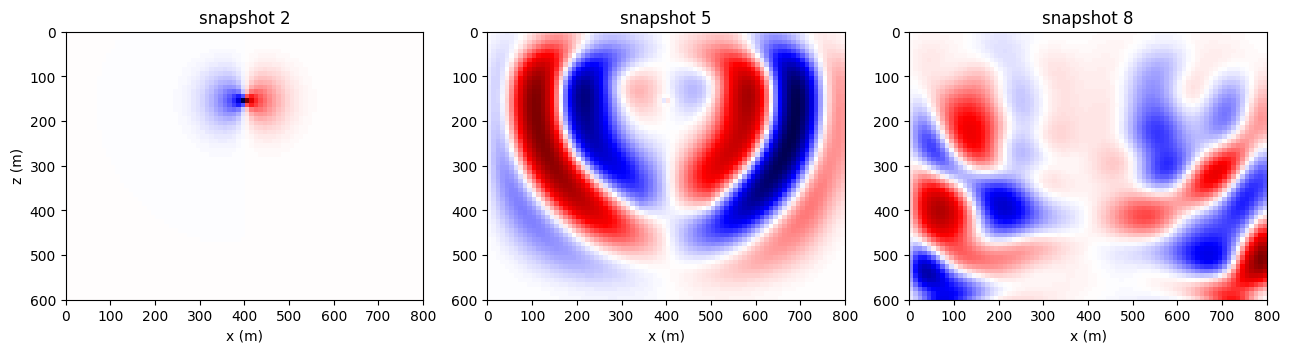

In [15]:
movvx = np.squeeze(mov[0])            # -> (NZ, NX, nframes)
print("movvx after squeeze:", movvx.shape)

frames = [2, 5, 8]
fig, axes = plt.subplots(1, len(frames), figsize=(13, 3.6))
for ax, k in zip(axes, frames):
    snap = movvx[..., k]
    v = np.abs(snap).max()
    ax.imshow(snap, cmap="seismic", vmin=-v, vmax=v,
              extent=[0, nx * seis.dh, nz * seis.dh, 0])
    ax.set_title("snapshot %d" % k)
    ax.set_xlabel("x (m)")
axes[0].set_ylabel("z (m)")
plt.tight_layout(); plt.show()

## Reading SeisCL's files without SeisCL

Nothing above needs the `SeisCL` class -- the files are ordinary HDF5. To load a
gradient in another tool, transpose and you are done:

```python
import h5py as h5, numpy as np
with h5.File("seiscl/SeisCL_gout.mat", "r") as f:
    grad_vp = np.transpose(f["gradvp"][()])     # -> (NZ, NX)
```

Building inputs by hand is the same in reverse: write `_csts.mat` with the
whitelisted names (including `src_pos`, `rec_pos`, `src`), `_model.mat` with one
`float32` dataset per parameter, and `_din.mat` only if you need reference data.
Transpose everything.

## Gotchas, collected

- **Transpose on every read and write.** Disk shapes are the reverse of Python's.
- **`file_din` must be absolute** whenever `workdir` differs from the process's
  working directory, because `write_data()` and the subprocess command resolve it
  differently.
- **Reference data in `_din.mat` uses bare field names** (`vx`), while output data
  in `_dout.mat` uses `<field>out`.
- **`resout = 1` writes residuals into `_dout.mat`**, not `_res.mat`. `_res.mat`
  is the *input* file for `inputres = 1`.
- **`resout` output and `inputres` input are not the same quantity.** The former
  is the scaled adjoint source, the latter the plain residual; they differ by a
  configuration-dependent constant, so they do not round-trip.
- **`read_grad()` crops, `h5py` does not** -- expect an `nab`-wide disagreement
  at the borders.
- **`read_rms()` rescales** -- the on-disk `rms` is not the returned `rms`.
- **A misspelled parameter is silently dropped** by `write_csts()`'s whitelist
  filter, and the run proceeds with the default.

## See also

- [Computing the gradient](../Inversion/ComputingGradient.ipynb) -- what
  `_din.mat`, `_res.mat` and `_gout.mat` are actually for.
- [Reading and writing SEGY](10_ReadingWritingSEGY.ipynb) -- getting field data
  in and out.
- [Creating a movie](7_CreatingMovie.ipynb) -- more on `movout`.